# CP8305 Final Project
## Notebook 1 – Data Exploration

**Team members:** Christopher Indris; Mojtaba Mohammadi; Mohammad Al Batayeh  
**Date:** 2026-03-08

---

### Instructions
Run with a fresh 3.11 environment (I used a 3.11.11 venv "cp8305fp").
Ensure that you pip install ipykernel to run the notebook.

---

### Objectives
- Load the raw dataset and inspect its structure.
- Summarise key statistics and data types.
- Visualise distributions, missing values, and correlations.
- Document initial observations to guide preprocessing decisions.

## 1. Setup

### Installation

In [21]:
%pip install --upgrade pip
%pip install ucimlrepo # for loading the dataset
%pip install scikit-learn # for data splitting and function application
%pip install matplotlib # for plotting
%pip install seaborn # for statistical plotting
%pip install mlxtend # for association rules

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


### Imports

In [22]:
import sys
from pathlib import Path

# Allow imports from the src package
sys.path.insert(0, str(Path('..').resolve()))

import io
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.visualization import (
    plot_missing_values,
    plot_distribution,
    plot_correlation_heatmap,
    plot_boxplots,
    plot_count,
    plot_scatter,
    save_figure,
)

from mlxtend.frequent_patterns import fpgrowth, association_rules
from src.visualization import plot_association_rules

sns.set_theme(style='whitegrid')
%matplotlib inline

## 2. Load Data

In [23]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
diabetes_130_us_hospitals_for_years_1999_2008 = fetch_ucirepo(id=296) 
  
# data (as pandas dataframes) 
X = diabetes_130_us_hospitals_for_years_1999_2008.data.features 
y = diabetes_130_us_hospitals_for_years_1999_2008.data.targets 
idXy = diabetes_130_us_hospitals_for_years_1999_2008.data.original


/Users/chrisindris/.pyenv/versions/cp8305fp/lib/python3.11/site-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


### Mappings for encoded values

In [24]:
def read_multiple_tables_csv(filepath, table_delimiter=',\n'):
    """
    Reads a single CSV file containing multiple tables into a list of DataFrames.
    """
    with open(filepath, "r") as f:
        csv_content = f.read()
    
    # Split the content into a list of strings, one for each table
    csv_tables_list = csv_content.split(table_delimiter)
    
    # Convert each string segment into a DataFrame
    dataframe_list = [pd.read_csv(io.StringIO(table_data)) for table_data in csv_tables_list if table_data.strip()]
    
    return dataframe_list

In [25]:
admission_type_ids, discharge_disposition_ids, admission_source_id = read_multiple_tables_csv('../data/diabetes130/raw/IDS_mapping.csv')

In [26]:
admission_type_ids

,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available
5,6,NaN
6,7,Trauma Center
7,8,Not Mapped


In [27]:
discharge_disposition_ids

,discharge_disposition_id,description
0,1,Discharged to home
1,2,Discharged/transferred to another short term h...
2,3,Discharged/transferred to SNF
3,4,Discharged/transferred to ICF
4,5,Discharged/transferred to another type of inpa...
5,6,Discharged/transferred to home with home healt...
6,7,Left AMA
7,8,Discharged/transferred to home under care of H...
8,9,Admitted as an inpatient to this hospital
9,10,Neonate discharged to another hospital for neo...


In [28]:
admission_source_id

,admission_source_id,description
0,1,Physician Referral
1,2,Clinic Referral
2,3,HMO Referral
3,4,Transfer from a hospital
4,5,Transfer from a Skilled Nursing Facility (SNF)
5,6,Transfer from another health care facility
6,7,Emergency Room
7,8,Court/Law Enforcement
8,9,Not Available
9,10,Transfer from critial access hospital


### Variable Info

**IDs (present in idXy but not in X or y):**
We would filter by these, but not fit models to them.

encounter_id: for tracking individual admissions \
patient_nbr: for tracking individual patients (we can use this in tandem with the readmissions column)

In [29]:
set(idXy.columns) - set(X.columns) 

{'encounter_id', 'patient_nbr', 'readmitted'}

**y: Target Variable**

the data is surprisingly balanced. There are no missing values.

Papers in the literature do the following (Strack et al. (2014), which was the original paper, and Emi-Johnson (2025)): \
NO and >30 -> NO \
<30 -> YES (as in, yes they were readmitted soon after) \
(this does make the target less balanced, but not catastrophically so; there are also techniques to deal with this)
This is most in line with what hospitals consider "readmission")

Current plan:
- We will go binary, as shown above.
- However: We should do some experiments where they are separate (since the time between admissions likely says something about severity; and the readmission may or may not have the same diagnosis/cause as the original (we can consult the diagnosis IDs to see if they were readmitted for the same reason or for something else)). Linear regression would be good to do on both versions since it gives you a sense of how important each input variable is for predicting the output (i.e. relative importance).

In [30]:
y.value_counts()

readmitted
NO            54864
>30           35545
<30           11357
Name: count, dtype: int64

In [31]:
y_binary = y.copy()
y_binary['readmitted_binary'] = y['readmitted'].apply(lambda x: 1 if x == '<30' else 0)
y_binary.drop(columns=['readmitted'], inplace=True)

In [32]:
idXybin = idXy.copy()
idXy.drop(columns=['readmitted'], inplace=True)
idXybin['readmitted_binary'] = y_binary

**Missing Values**

See section 4 for cleanup of missing values.

Since weight is ordinal categorical (based on ranges), we might be able to estimate the missing values.
For the other ones, we will replace "NaN" values with the string category "NA" (we will keep these rows, but we do need to convert them from NaN because if we don't SKLearn will crash).

In [33]:
diabetes_130_us_hospitals_for_years_1999_2008.variables[diabetes_130_us_hospitals_for_years_1999_2008.variables.missing_values == 'yes']

,name,role,type,demographic,description,units,missing_values
2,race,Feature,Categorical,Race,"Values: Caucasian, Asian, African American, Hi...",None,yes
5,weight,Feature,Categorical,NaN,Weight in pounds.,None,yes
10,payer_code,Feature,Categorical,NaN,Integer identifier corresponding to 23 distinc...,None,yes
11,medical_specialty,Feature,Categorical,NaN,Integer identifier of a specialty of the admit...,None,yes
18,diag_1,Feature,Categorical,NaN,The primary diagnosis (coded as first three di...,None,yes
19,diag_2,Feature,Categorical,NaN,Secondary diagnosis (coded as first three digi...,None,yes
20,diag_3,Feature,Categorical,NaN,Additional secondary diagnosis (coded as first...,None,yes


In [34]:
X["weight"].value_counts()

weight
[75-100)     1336
[50-75)       897
[100-125)     625
[125-150)     145
[25-50)        97
[0-25)         48
[150-175)      35
[175-200)      11
>200            3
Name: count, dtype: int64

Note that the columns for diagnoses include missing values; hence, if we care about if the patient was readmitted for a different reason vs. the same reason as before, this might make a difference. However, it might not be a problem, but it could be something that we discuss (for example, we might list one limitation as the fact that we don't always know what the reason for admission/readmission is).

In [35]:
diabetes_130_us_hospitals_for_years_1999_2008.variables[diabetes_130_us_hospitals_for_years_1999_2008.variables.missing_values == 'yes'].description.values

<StringArray>
[                                                                                                                    'Values: Caucasian, Asian, African American, Hispanic, and other',
                                                                                                                                                                   'Weight in pounds.',
                                                                 'Integer identifier corresponding to 23 distinct values, for example, Blue Cross/Blue Shield, Medicare, and self-pay',
 'Integer identifier of a specialty of the admitting physician, corresponding to 84 distinct values, for example, cardiology, internal medicine, family/general practice, and surgeon',
                                                                                                    'The primary diagnosis (coded as first three digits of ICD9); 848 distinct values',
                                                                  

In [36]:
# metadata 
print(json.dumps(diabetes_130_us_hospitals_for_years_1999_2008.metadata, indent=4)) # metadata

{
    "uci_id": 296,
    "name": "Diabetes 130-US Hospitals for Years 1999-2008",
    "repository_url": "https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008",
    "data_url": "https://archive.ics.uci.edu/static/public/296/data.csv",
    "abstract": "The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. Each row concerns hospital records of patients diagnosed with diabetes, who underwent laboratory, medications, and stayed up to 14 days. The goal is to determine the early readmission of the patient within 30 days of discharge.\nThe problem is important for the following reasons. Despite high-quality evidence showing improved clinical outcomes for diabetic patients who receive various preventive and therapeutic interventions, many patients do not receive them. This can be partially attributed to arbitrary diabetes management in hospital environments, which fail to attend to glycemic control. F

In [37]:
# variable information 
print(diabetes_130_us_hospitals_for_years_1999_2008.variables) 

                        name     role         type demographic  \
0               encounter_id       ID                      NaN   
1                patient_nbr       ID                      NaN   
2                       race  Feature  Categorical        Race   
3                     gender  Feature  Categorical      Gender   
4                        age  Feature  Categorical         Age   
5                     weight  Feature  Categorical         NaN   
6          admission_type_id  Feature  Categorical         NaN   
7   discharge_disposition_id  Feature  Categorical         NaN   
8        admission_source_id  Feature  Categorical         NaN   
9           time_in_hospital  Feature      Integer         NaN   
10                payer_code  Feature  Categorical         NaN   
11         medical_specialty  Feature  Categorical         NaN   
12        num_lab_procedures  Feature      Integer         NaN   
13            num_procedures  Feature      Integer         NaN   
14        

In [38]:
idXy.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 49 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      99493 non-null   str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    3197 non-null    str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                61510 non-null   str  
 11  medical_specialty         51817 non-null   str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

## 3. Basic Inspection

In [39]:
# the dataset with the ids, X and y
print(f'Shape: {idXy.shape}')
idXy.head()

Shape: (101766, 49)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,No
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,No,Up,No,No,No,No,No,Ch,Yes
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,No,Yes
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,No,Up,No,No,No,No,No,Ch,Yes
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,No,Steady,No,No,No,No,No,Ch,Yes


Why are some of the "unique" column values listed as "not a number"? Is it because they are numeric? We will need to inspect what the possible values of them are.

In [40]:
idXy.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
encounter_id,101766.0,NaN,NaN,NaN,165201645.622978,102640295.983457,12522.0,84961194.0,152388987.0,230270887.5,443867222.0
patient_nbr,101766.0,NaN,NaN,NaN,54330400.694947,38696359.346534,135.0,23413221.0,45505143.0,87545949.75,189502619.0
race,99493,5,Caucasian,76099,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,101766,3,Female,54708,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,101766,10,[70-80),26068,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight,3197,9,[75-100),1336,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admission_type_id,101766.0,NaN,NaN,NaN,2.024006,1.445403,1.0,1.0,1.0,3.0,8.0
discharge_disposition_id,101766.0,NaN,NaN,NaN,3.715642,5.280166,1.0,1.0,1.0,4.0,28.0
admission_source_id,101766.0,NaN,NaN,NaN,5.754437,4.064081,1.0,1.0,7.0,7.0,25.0
time_in_hospital,101766.0,NaN,NaN,NaN,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0


Limitation: we don't know the dosages of the medications that the patients were on.

In [41]:
diabetes_130_us_hospitals_for_years_1999_2008.variables.description.values

<StringArray>
[                                                                                                                                                                                                                                   'Unique identifier of an encounter',
                                                                                                                                                                                                                                       'Unique identifier of a patient',
                                                                                                                                                                                                      'Values: Caucasian, Asian, African American, Hispanic, and other',
                                                                                                                                                                                               

## 4. Missing Values

In [42]:
columns_with_missing_values = diabetes_130_us_hospitals_for_years_1999_2008.variables[diabetes_130_us_hospitals_for_years_1999_2008.variables.missing_values == 'yes'].name.tolist()

In [43]:
idXy[columns_with_missing_values].isna().sum()

race                  2273
weight               98569
payer_code           40256
medical_specialty    49949
diag_1                  21
diag_2                 358
diag_3                1423
dtype: int64

In [44]:
idXy['weight'].value_counts(dropna=False)

weight
NaN          98569
[75-100)      1336
[50-75)        897
[100-125)      625
[125-150)      145
[25-50)         97
[0-25)          48
[150-175)       35
[175-200)       11
>200             3
Name: count, dtype: int64

For some columns (including weight, which is perhaps the most estimatable since it is ordinal), nearly all values are missing.

Missing value percentage per column:
weight               96.858479
max_glu_serum        94.746772
A1Cresult            83.277322
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
Figure saved to /Users/chrisindris/Documents/PhD/CP8305-KD/Project/CP8305FP/reports/figures/01_missing_values.png


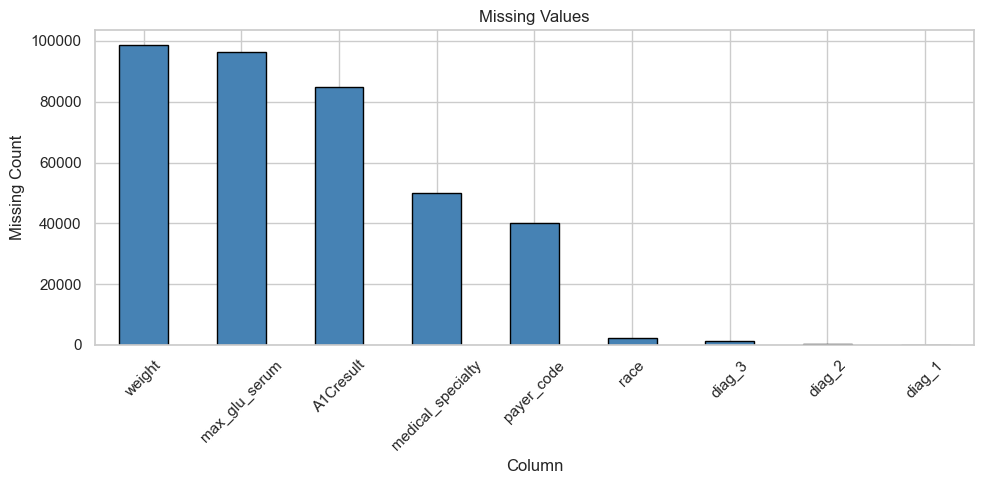

In [45]:
missing_pct = idXy.isnull().mean().sort_values(ascending=False) * 100
print('Missing value percentage per column:')
print(missing_pct[missing_pct > 0].to_string())

fig = plot_missing_values(idXy)
save_figure(fig, '01_missing_values.png')

### Remove Duplicates

There are no duplicates to drop.

In [46]:
int(X.duplicated().sum()), int(idXy.duplicated().sum())

(0, 0)

## 5. Univariate Analysis

Numeric columns: ['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
Figure saved to /Users/chrisindris/Documents/PhD/CP8305-KD/Project/CP8305FP/reports/figures/01_distributions.png


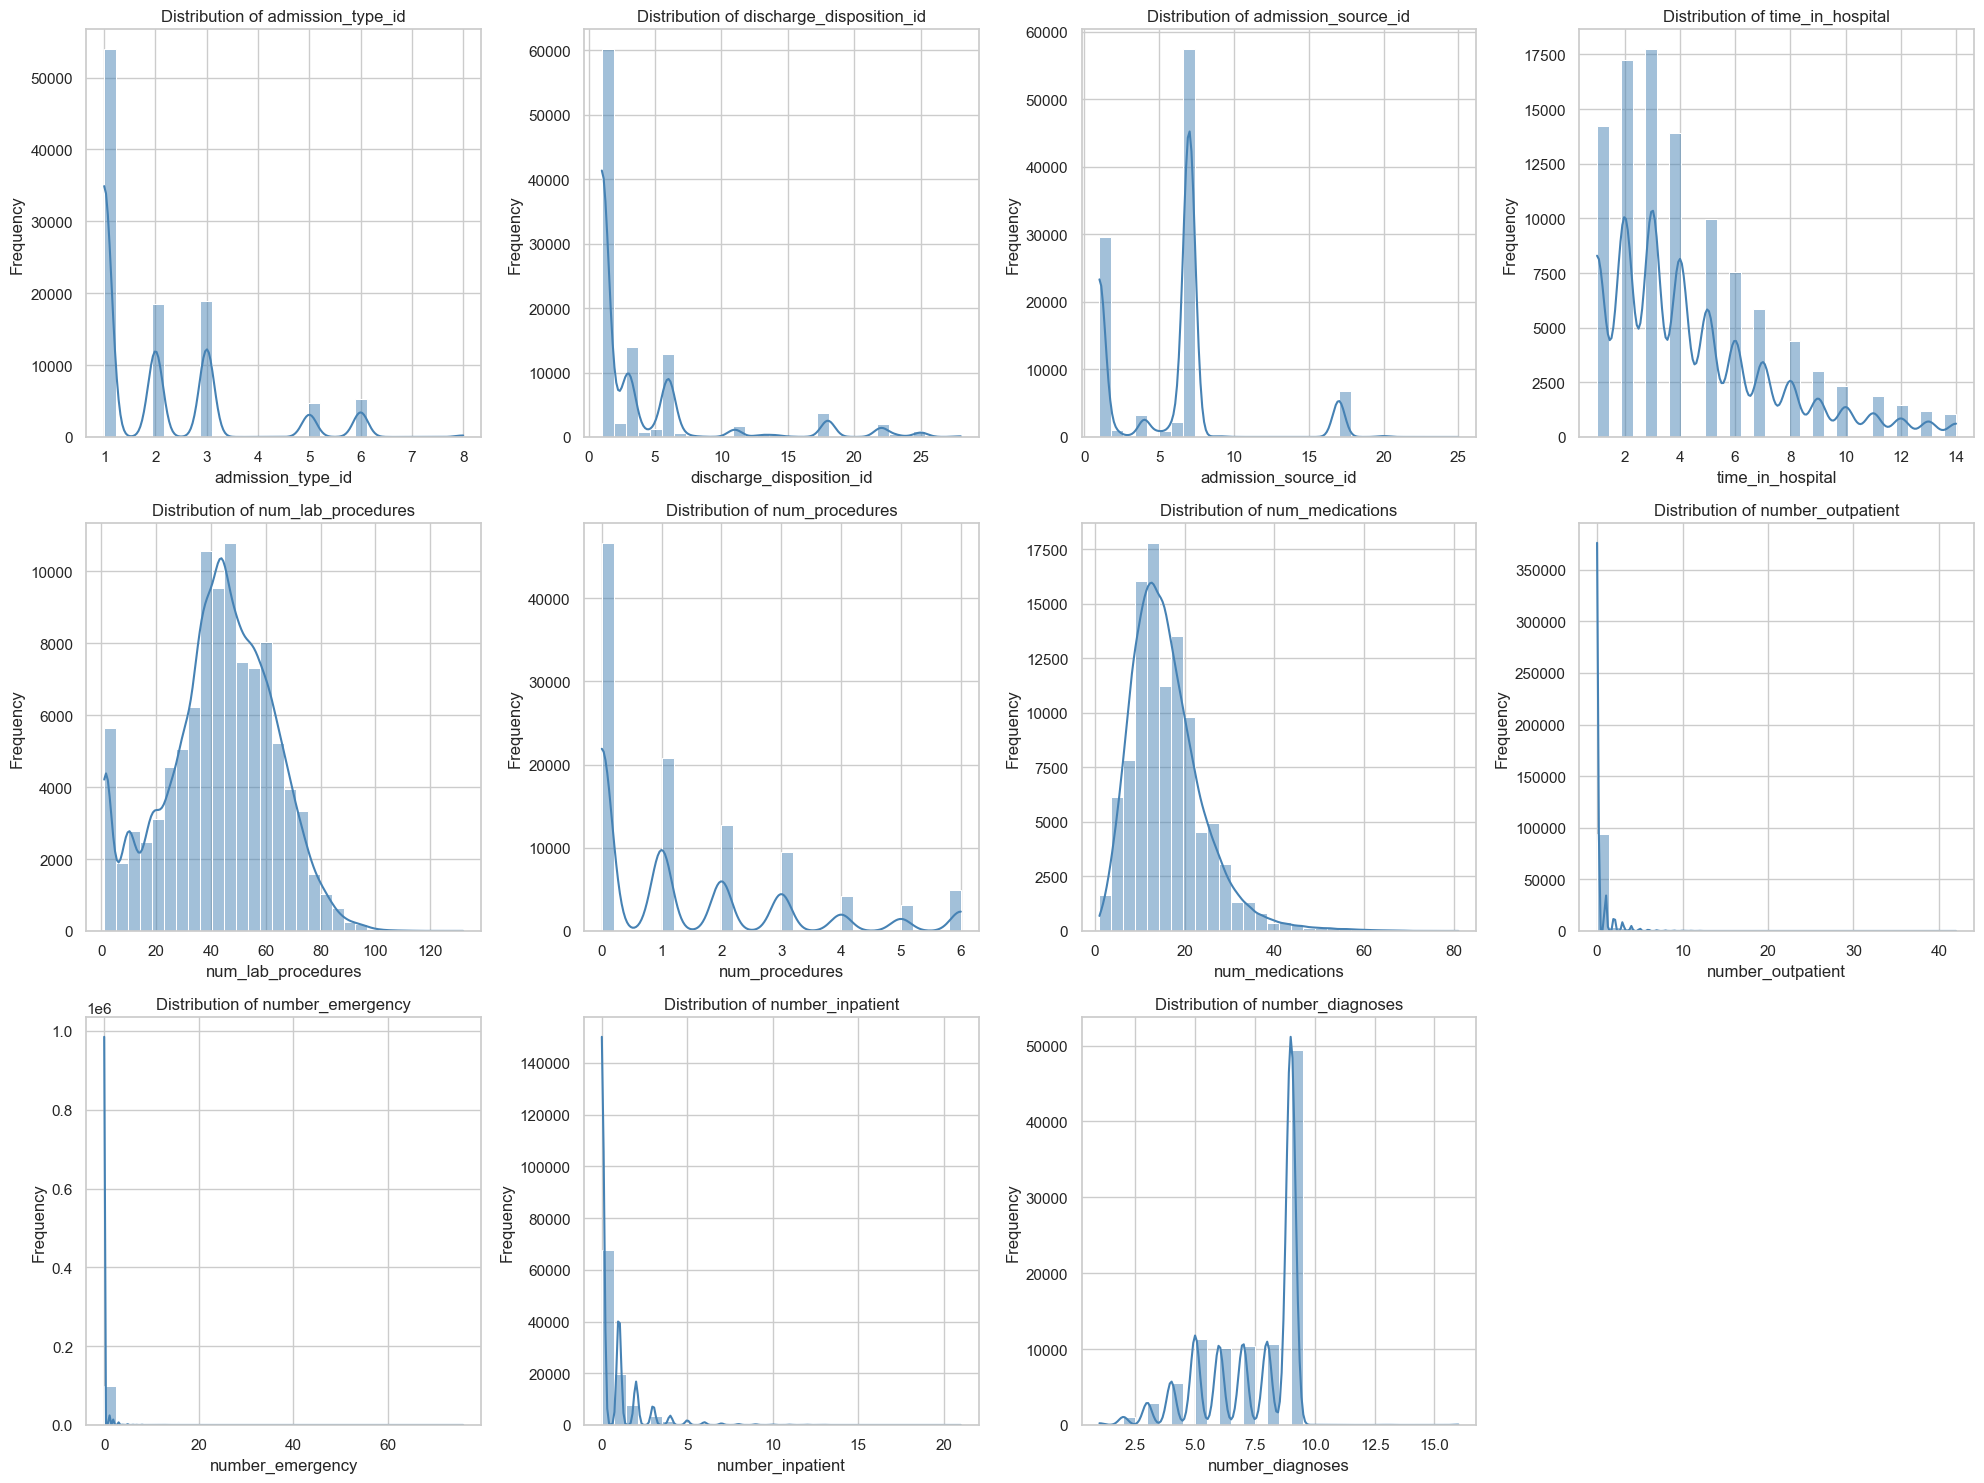

In [47]:
# The numeric columns, without the visit and patient IDs.
numeric_cols = idXy.select_dtypes(include=np.number).drop(columns=['encounter_id', 'patient_nbr']).columns.tolist()
print('Numeric columns:', numeric_cols)

# for col in numeric_cols:  # Limit to first 6 to keep output manageable
#     fig = plot_distribution(idXy, col)
#     save_figure(fig, f'01_dist_{col}.png')
#     plt.show()
fig = plot_distribution(idXy, numeric_cols, 3)
save_figure(fig, '01_distributions.png')
plt.show()

Figure saved to /Users/chrisindris/Documents/PhD/CP8305-KD/Project/CP8305FP/reports/figures/01_boxplots.png


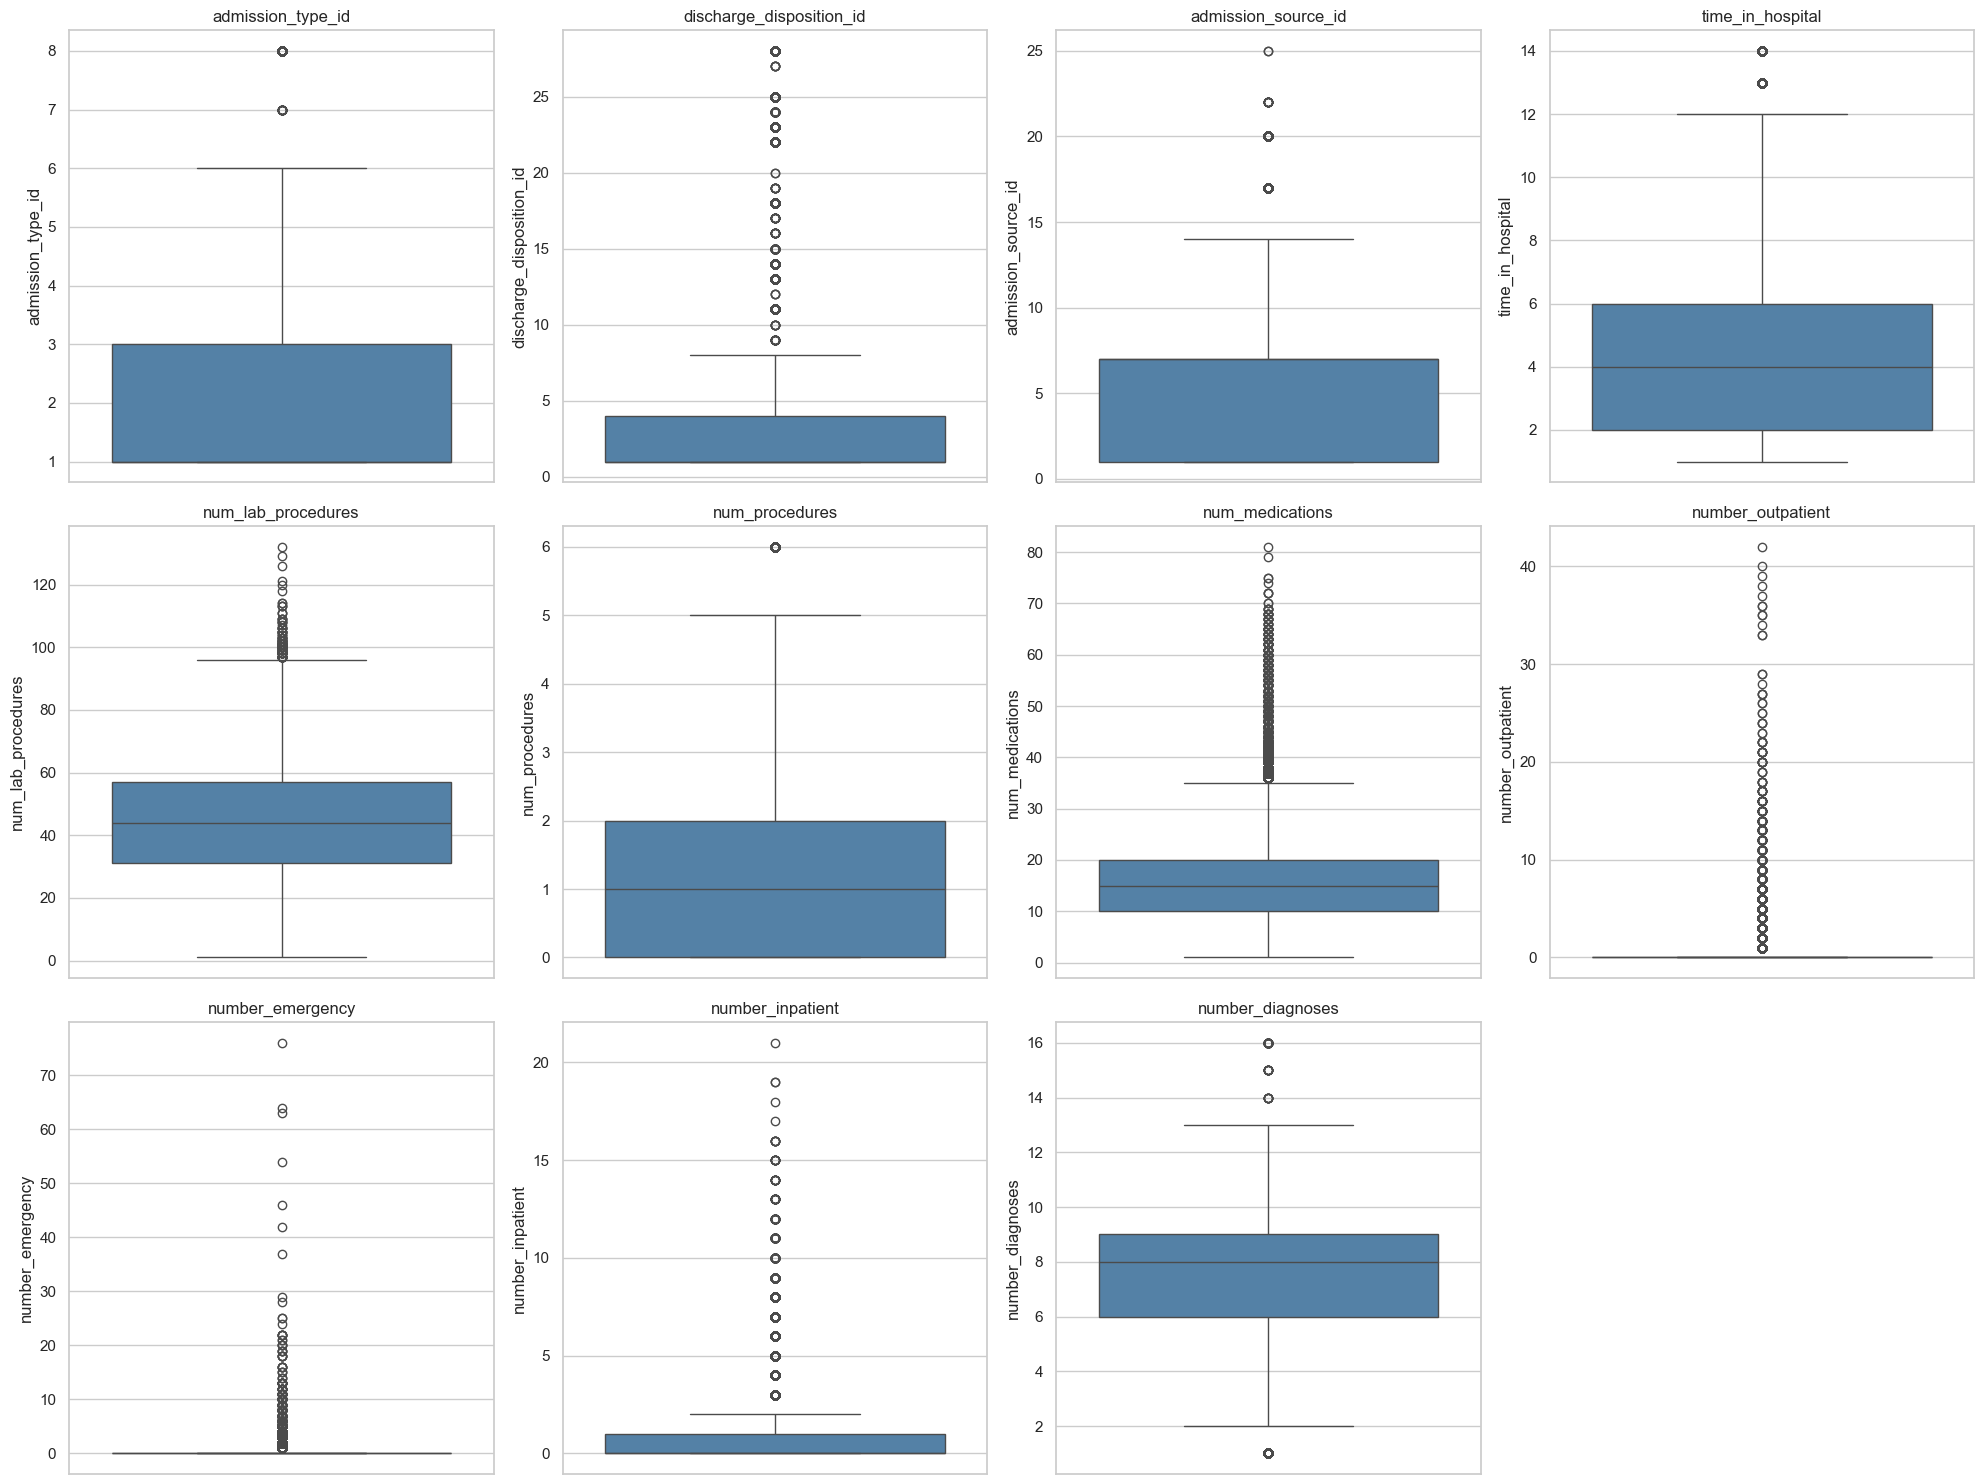

In [48]:
# Box plots for outlier detection
from src.visualization import plot_boxplots

fig = plot_boxplots(idXy, numeric_cols, 3)
save_figure(fig, '01_boxplots.png')
plt.show()


Categorical columns: ['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']
Figure saved to /Users/chrisindris/Documents/PhD/CP8305-KD/Project/CP8305FP/reports/figures/01_counts.png


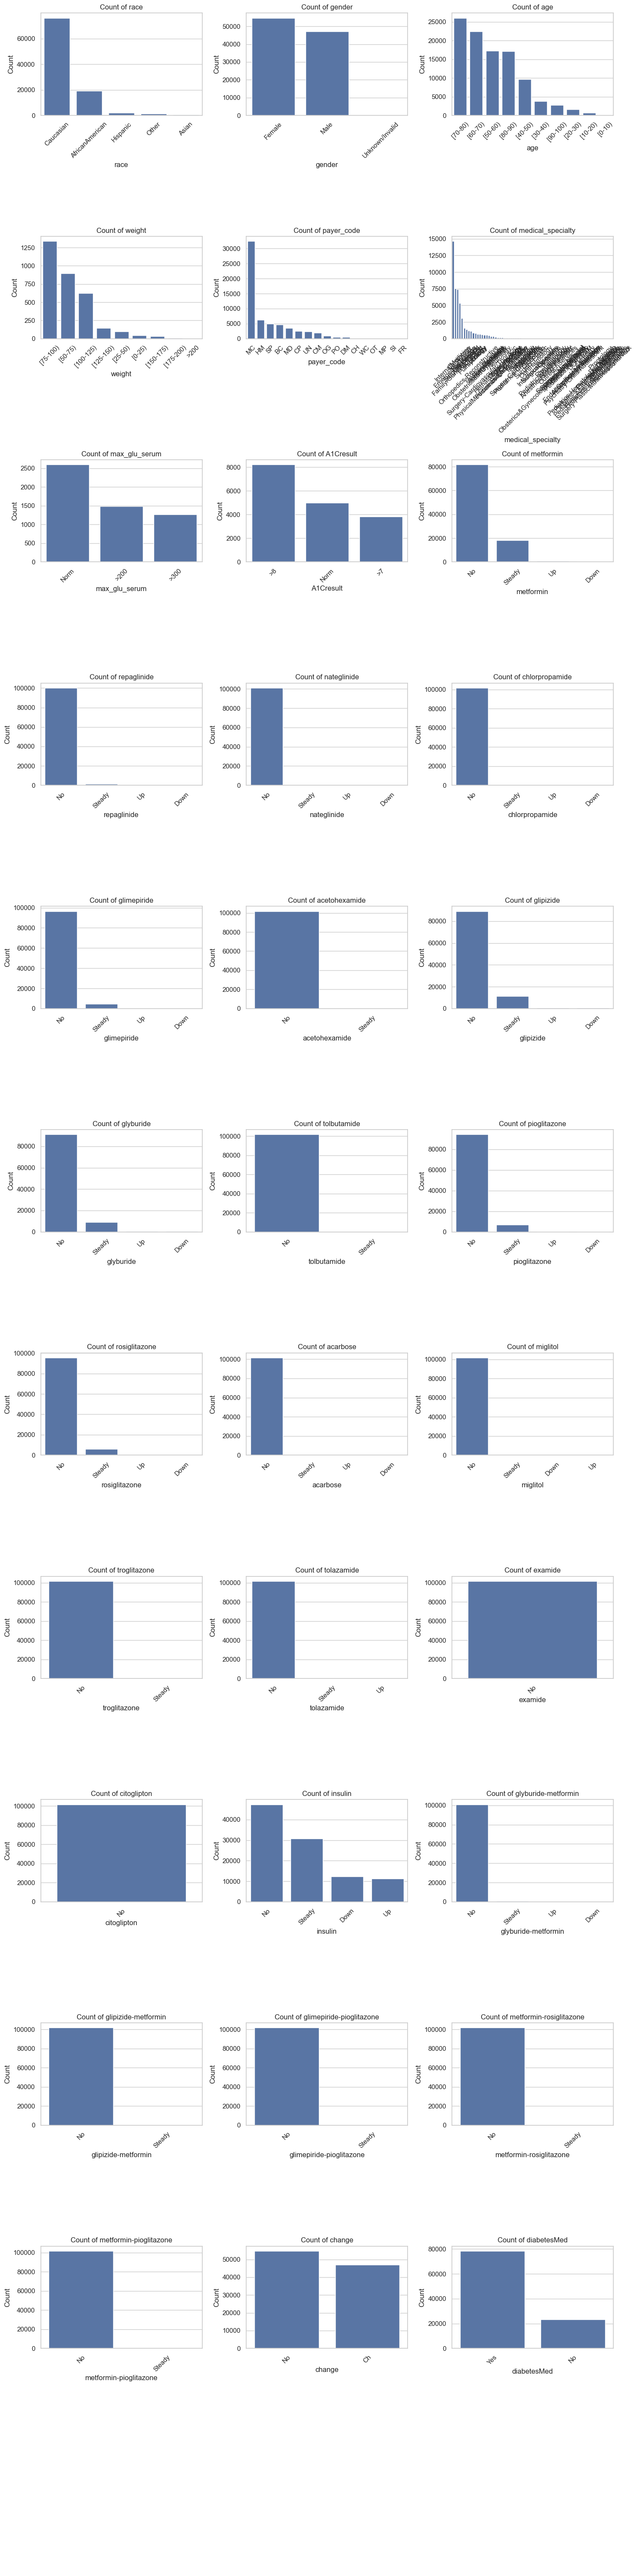

In [49]:
# Categorical columns

# let cat_cols be all columns in idXy where the type is str
cat_cols = idXy.select_dtypes(include=['str']).columns.tolist()

print('Categorical columns:', cat_cols)

# for col in cat_cols:
#     if (col != 'medical_specialty') and ('diag' not in col): # these have too many categories to plot
#         fig = plot_count(idXy, col)
#         save_figure(fig, f'01_count_{col}.png')
#         plt.show()
fig = plot_count(idXy, [c for c in cat_cols if 'diag' not in c], 12)
save_figure(fig, '01_counts.png')
plt.show()

In [50]:
idXy['medical_specialty'].value_counts()

medical_specialty
InternalMedicine          14635
Emergency/Trauma           7565
Family/GeneralPractice     7440
Cardiology                 5352
Surgery-General            3099
                          ...  
Dermatology                   1
SportsMedicine                1
Speech                        1
Perinatology                  1
Neurophysiology               1
Name: count, Length: 72, dtype: int64

In [51]:
idXy['diag_1'].value_counts()

diag_1
428    6862
414    6581
786    4016
410    3614
486    3508
       ... 
833       1
391       1
690       1
10        1
V51       1
Name: count, Length: 716, dtype: int64

In [52]:
idXy['diag_2'].value_counts()

diag_2
276    6752
428    6662
250    6071
427    5036
401    3736
       ... 
123       1
884       1
V60       1
843       1
927       1
Name: count, Length: 748, dtype: int64

In [53]:
idXy['diag_3'].value_counts()

diag_3
250    11555
401     8289
276     5175
428     4577
427     3955
       ...  
14         1
750        1
370        1
671        1
971        1
Name: count, Length: 789, dtype: int64

In [54]:
idXy['max_glu_serum'].value_counts(dropna=False)

max_glu_serum
NaN     96420
Norm     2597
>200     1485
>300     1264
Name: count, dtype: int64

## 6. Bivariate Analysis

In [55]:
# we have create a version of idXy where we have readmitted_binary which is 1 if and only if readmitted is '<30'
#idXy['readmitted_binary'] = idXy['readmitted'].apply(lambda x: 1 if x == '<30' else 0)
idXybin['readmitted_binary'].value_counts()


readmitted_binary
0    90409
1    11357
Name: count, dtype: int64

Figure saved to /Users/chrisindris/Documents/PhD/CP8305-KD/Project/CP8305FP/reports/figures/01_correlation_heatmap.png


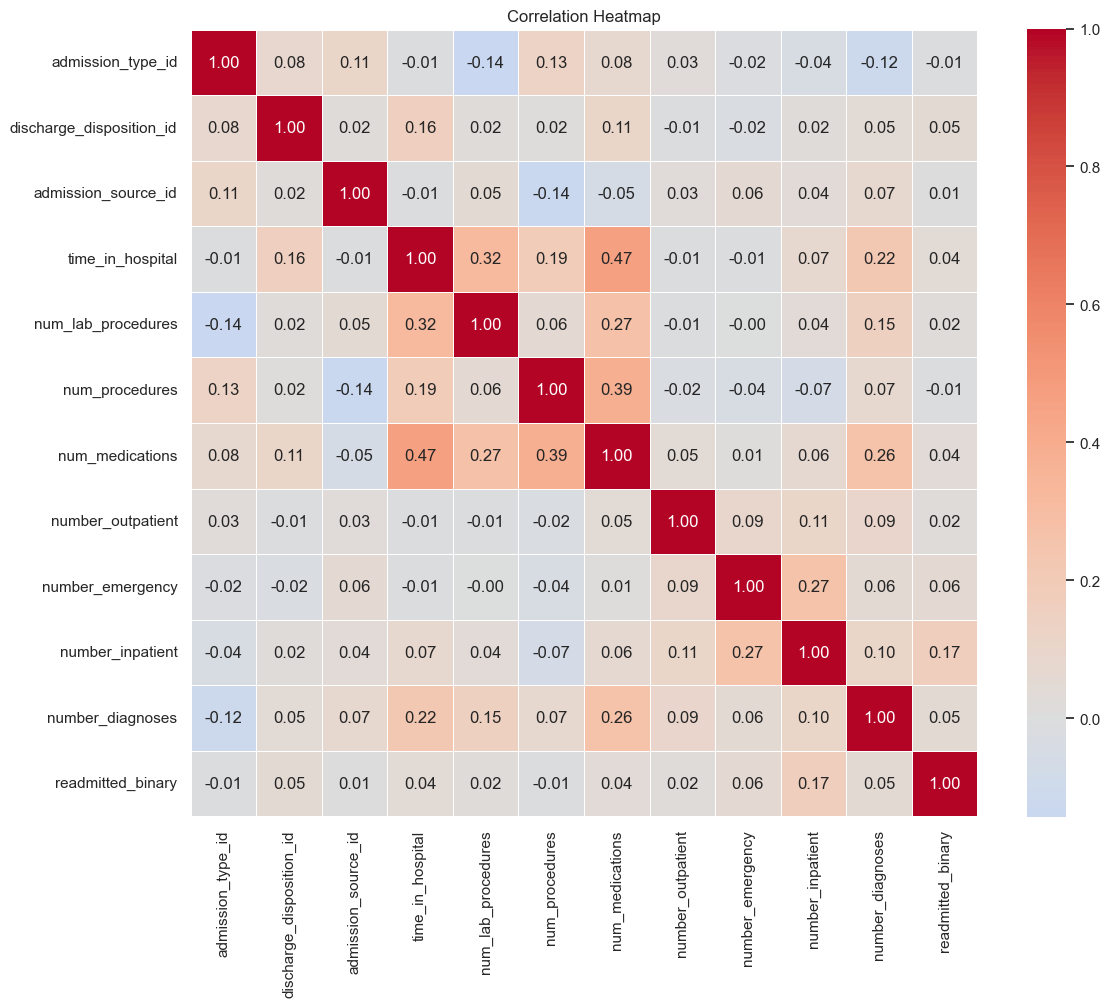

In [56]:
# Correlation heatmap
fig = plot_correlation_heatmap(idXybin.drop(columns=['encounter_id', 'patient_nbr']))
save_figure(fig, '01_correlation_heatmap.png')
plt.show()

Figure saved to /Users/chrisindris/Documents/PhD/CP8305-KD/Project/CP8305FP/reports/figures/01_scatters.png


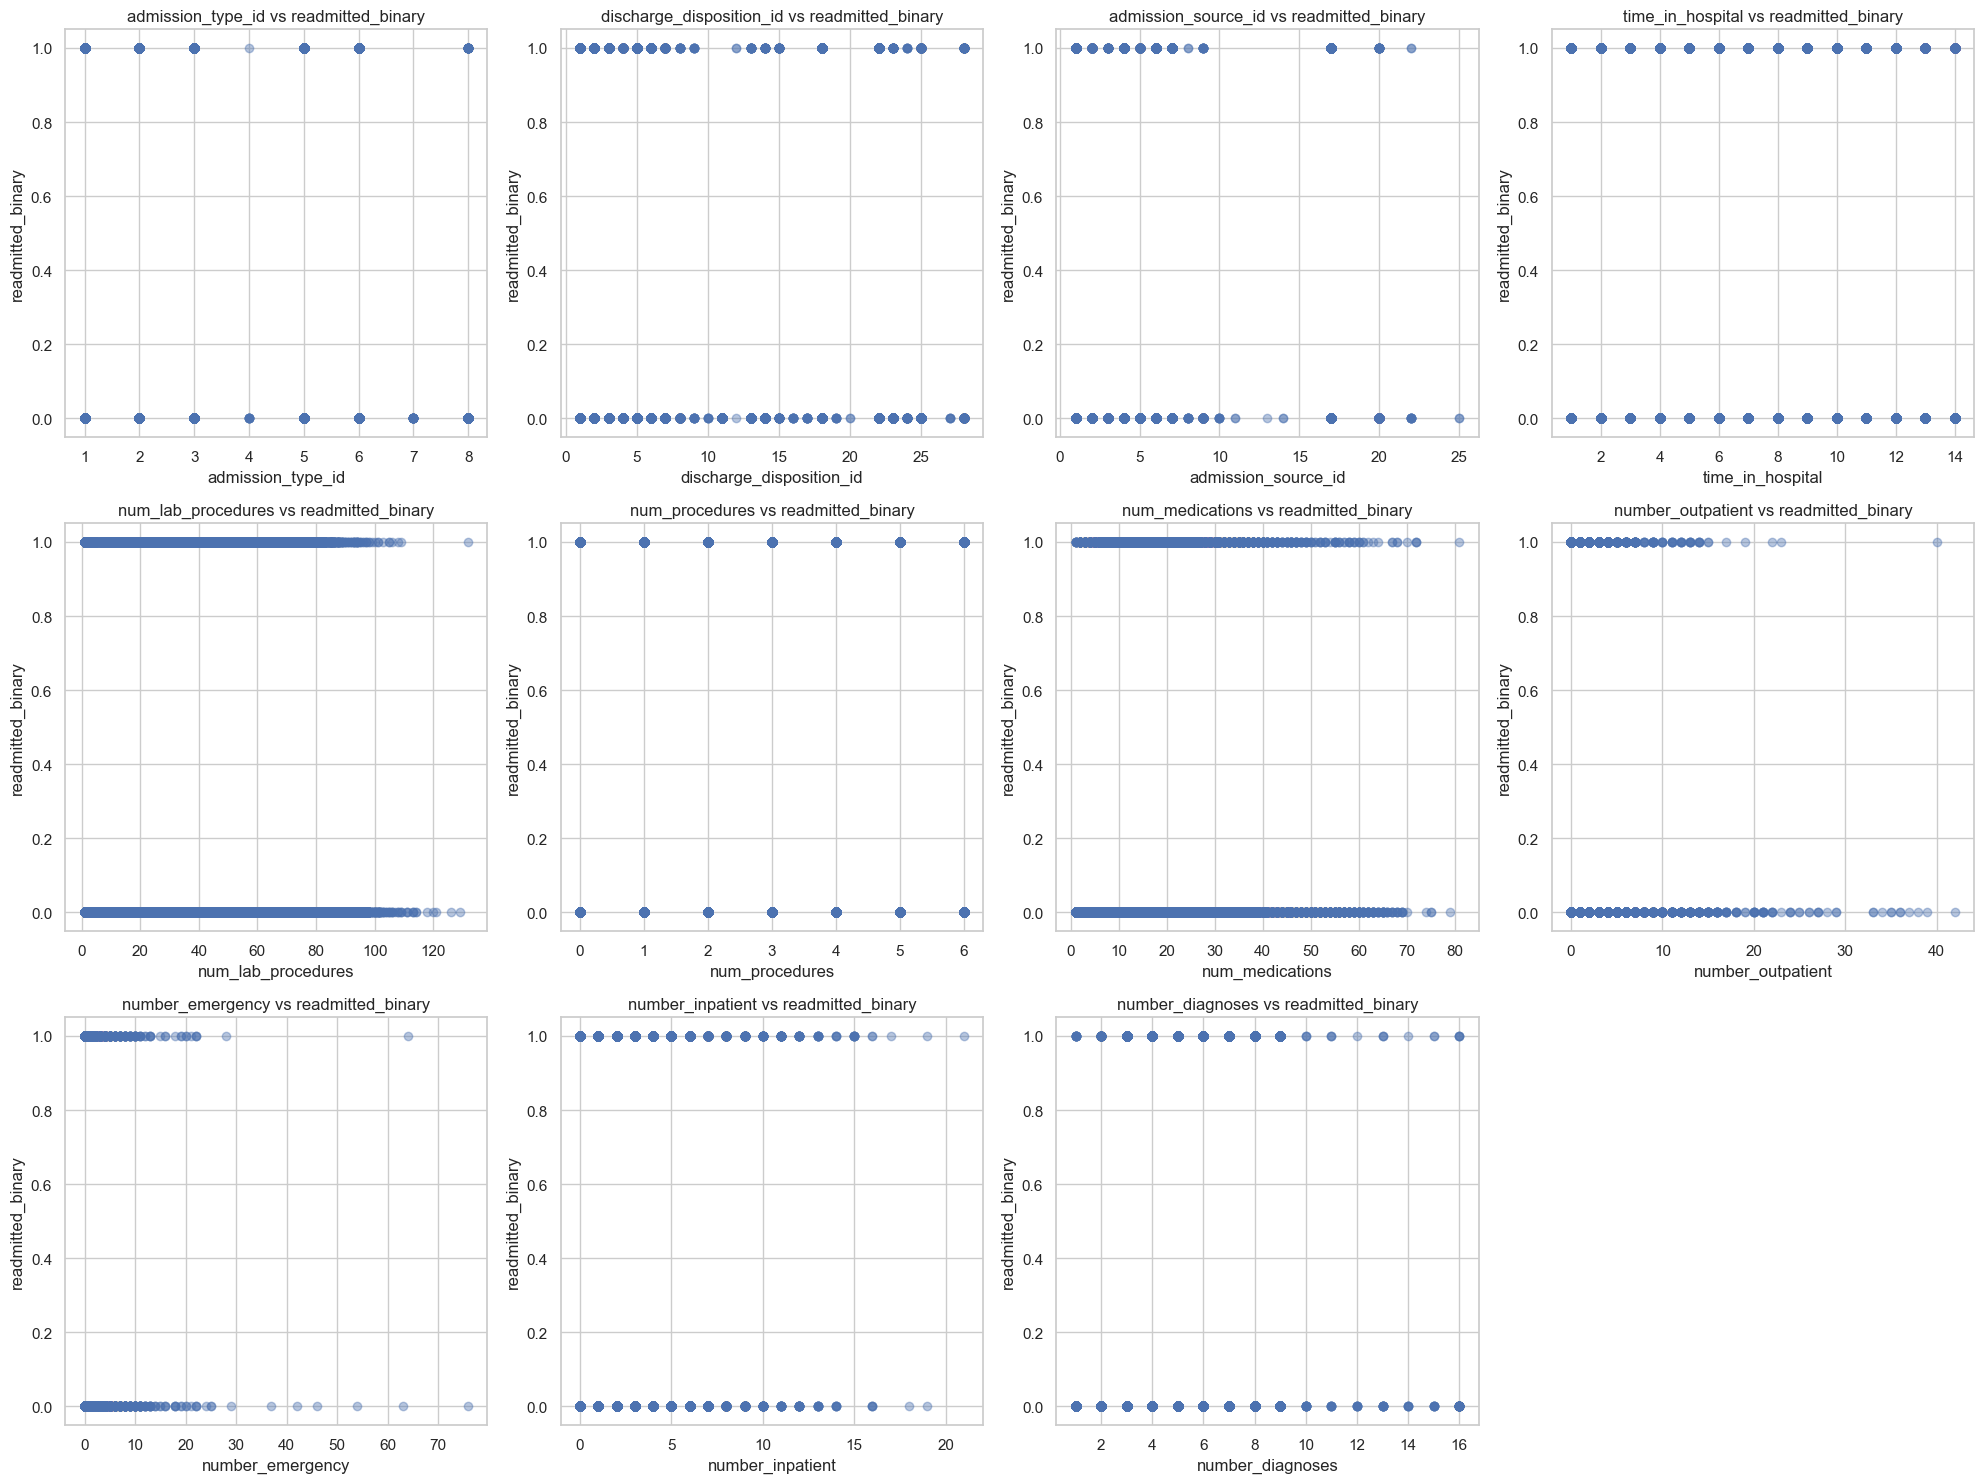

In [57]:
# TODO: Update target_column to your actual target variable.
target_column = 'readmitted_binary'  # <-- Change this

# if target_column in idXy.columns:
#     for col in numeric_cols:
#         if col != target_column:
#             fig, ax = plt.subplots(figsize=(6, 4))
#             ax.scatter(idXy[col], idXy[target_column], alpha=0.4)
#             ax.set_xlabel(col)
#             ax.set_ylabel(target_column)
#             ax.set_title(f'{col} vs {target_column}')
#             plt.tight_layout()
#             save_figure(fig, f'01_scatter_{col}_vs_{target_column}.png')
#             plt.show()
fig = plot_scatter(idXybin, numeric_cols, 3)
save_figure(fig, '01_scatters.png')
plt.show()

We might also want to know the cardinality of each column.

In [58]:
# calculate the cardinality of each column, and sort by cardinality
idXybin.nunique().sort_values(ascending=False)


encounter_id                101766
patient_nbr                  71518
diag_3                         789
diag_2                         748
diag_1                         716
num_lab_procedures             118
num_medications                 75
medical_specialty               72
number_outpatient               39
number_emergency                33
discharge_disposition_id        26
number_inpatient                21
payer_code                      17
admission_source_id             17
number_diagnoses                16
time_in_hospital                14
age                             10
weight                           9
admission_type_id                8
num_procedures                   7
race                             5
glipizide                        4
glyburide-metformin              4
insulin                          4
miglitol                         4
acarbose                         4
rosiglitazone                    4
pioglitazone                     4
glyburide           

## 7. Association Rules

Association rule mining is an unsupervised technique for discovering interesting co-occurrence patterns
in categorical data.  Given a set of transactions (here, patient encounters), the algorithm finds rules
of the form **{A, B} → {C}** — meaning items A and B frequently appear together with item C.

Three key metrics govern which rules are interesting:

| Metric | Meaning |
|---|---|
| **Support** | Fraction of encounters that contain the itemset. Higher support = more common pattern. |
| **Confidence** | P(consequent \| antecedent) — how reliably the right-hand side follows the left-hand side. |
| **Lift** | Confidence divided by the baseline probability of the consequent. Lift > 1 indicates a positive association beyond chance. |

We apply this to the diabetes dataset to surface hidden relationships among medications,
demographics, lab results, and readmission outcomes without pre-specifying a target variable.

In [59]:
medication_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
    'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
    'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone',
    'metformin-pioglitazone',
]
demographic_cols = ['age', 'race', 'gender']
clinical_cols = ['max_glu_serum', 'A1Cresult', 'change', 'diabetesMed', 'readmitted_binary']

ar_cols = medication_cols + demographic_cols + clinical_cols

ar_df = idXybin[ar_cols].copy()
ar_df['readmitted_binary'] = ar_df['readmitted_binary'].astype(str)

# One-hot encode every selected column into "column=value" boolean columns.
ar_encoded = pd.get_dummies(ar_df, prefix_sep='=')

# Drop "medication=No" columns for rarely prescribed drugs to reduce noise.
# Keep "No" only for the handful of widely prescribed meds where "No" is informative.
widely_prescribed = {'metformin', 'insulin', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone'}
drop_cols = [c for c in ar_encoded.columns
             if '=No' in c
             and c.split('=')[0] in medication_cols
             and c.split('=')[0] not in widely_prescribed]
ar_encoded.drop(columns=drop_cols, inplace=True)

ar_encoded = ar_encoded.astype(bool)
print(f'Transaction matrix: {ar_encoded.shape[0]:,} rows x {ar_encoded.shape[1]} items')
ar_encoded.head()

Transaction matrix: 101,766 rows x 84 items


,metformin=Down,metformin=No,metformin=Steady,metformin=Up,repaglinide=Down,repaglinide=Steady,repaglinide=Up,nateglinide=Down,nateglinide=Steady,nateglinide=Up,...,max_glu_serum=Norm,A1Cresult=>7,A1Cresult=>8,A1Cresult=Norm,change=Ch,change=No,diabetesMed=No,diabetesMed=Yes,readmitted_binary=0,readmitted_binary=1
0,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,True,False,True,False
1,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,True,True,False
2,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,True,False
3,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,True,True,False
4,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,True,True,False


In [60]:
frequent_itemsets = fpgrowth(ar_encoded, min_support=0.05, use_colnames=True)
print(f'Frequent itemsets found: {len(frequent_itemsets)}')

rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.2)
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)
print(f'Association rules (lift >= 1.2): {len(rules)}')

rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(20)

Frequent itemsets found: 13887
Association rules (lift >= 1.2): 402062


,antecedents,consequents,support,confidence,lift
0,"frozenset({insulin=No, pioglitazone=No, readmi...","frozenset({diabetesMed=No, race=Caucasian})",0.072234,0.713343,4.113211
1,"frozenset({diabetesMed=No, race=Caucasian})","frozenset({insulin=No, pioglitazone=No, readmi...",0.072234,0.416511,4.113211
2,"frozenset({diabetesMed=No, gender=Male, readmi...","frozenset({insulin=No, pioglitazone=No, race=C...",0.072234,0.777719,4.108672
3,"frozenset({insulin=No, pioglitazone=No, race=C...","frozenset({diabetesMed=No, gender=Male, readmi...",0.072234,0.381612,4.108672
4,"frozenset({diabetesMed=No, race=Caucasian})","frozenset({insulin=No, pioglitazone=No, gender...",0.079889,0.460649,4.098124
5,"frozenset({insulin=No, pioglitazone=No, gender...","frozenset({diabetesMed=No, race=Caucasian})",0.079889,0.710726,4.098124
6,"frozenset({diabetesMed=No, gender=Male})","frozenset({insulin=No, pioglitazone=No, race=C...",0.079889,0.775689,4.097950
7,"frozenset({insulin=No, pioglitazone=No, race=C...","frozenset({diabetesMed=No, gender=Male})",0.079889,0.422053,4.097950
8,"frozenset({insulin=No, pioglitazone=No, race=C...","frozenset({diabetesMed=No, gender=Male})",0.072234,0.421454,4.092137
9,"frozenset({diabetesMed=No, gender=Male})","frozenset({insulin=No, pioglitazone=No, race=C...",0.072234,0.701364,4.092137


### How to read the rules

Each row in the table above is a rule **{antecedents} → {consequents}**:

- **Support** — the proportion of all encounters where both the antecedent and consequent items co-occur.
  A higher support means the pattern is more prevalent in the dataset.
- **Confidence** — P(consequent | antecedent).  A confidence of 0.80 means that 80% of encounters
  containing the antecedent items also contain the consequent items.
- **Lift** — confidence / P(consequent).  Lift > 1 signals a positive association stronger than
  what we would expect by chance; lift < 1 signals a negative (repulsive) association.

Rules with **high lift _and_ reasonable support** are the most interesting — they represent
strong, non-trivial patterns that occur frequently enough to be clinically meaningful.

Figure saved to /Users/chrisindris/Documents/PhD/CP8305-KD/Project/CP8305FP/reports/figures/01_association_rules.png


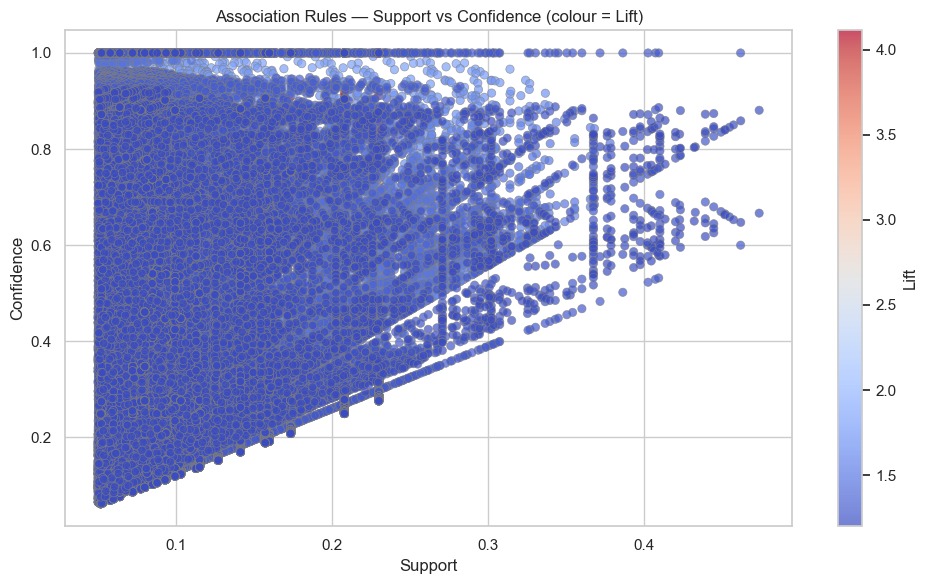

In [61]:
fig = plot_association_rules(rules, title='Association Rules — Support vs Confidence (colour = Lift)')
save_figure(fig, '01_association_rules.png')
plt.show()

In [62]:
readmission_items = {'readmitted_binary=1', 'readmitted_binary=0'}

def involves_readmission(row):
    return bool((set(row['antecedents']) | set(row['consequents'])) & readmission_items)

readmit_rules = rules[rules.apply(involves_readmission, axis=1)].copy()
readmit_rules = readmit_rules.sort_values('confidence', ascending=False).reset_index(drop=True)
print(f'Rules involving readmitted_binary: {len(readmit_rules)}')

readmit_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(20)

Rules involving readmitted_binary: 253880


,antecedents,consequents,support,confidence,lift
0,"frozenset({diabetesMed=No, glyburide=No, gende...","frozenset({glipizide=No, change=No, rosiglitaz...",0.092880,1.0,2.026363
1,"frozenset({pioglitazone=No, diabetesMed=No, re...",frozenset({change=No}),0.051648,1.0,1.858570
2,"frozenset({insulin=No, diabetesMed=No, pioglit...",frozenset({change=No}),0.115009,1.0,1.858570
3,"frozenset({insulin=No, diabetesMed=No, readmit...",frozenset({change=No}),0.207899,1.0,1.858570
4,"frozenset({pioglitazone=No, diabetesMed=No, ra...",frozenset({change=No}),0.072234,1.0,1.858570
5,"frozenset({insulin=No, diabetesMed=No, readmit...",frozenset({change=No}),0.207899,1.0,1.858570
6,"frozenset({insulin=No, diabetesMed=No, pioglit...",frozenset({change=No}),0.051648,1.0,1.858570
7,"frozenset({insulin=No, diabetesMed=No, readmit...",frozenset({change=No}),0.207899,1.0,1.858570
8,"frozenset({pioglitazone=No, diabetesMed=No, ra...",frozenset({change=No}),0.157125,1.0,1.858570
9,"frozenset({glipizide=No, diabetesMed=No, readm...",frozenset({change=No}),0.115009,1.0,1.858570


### Key findings

_Fill in after running the cells above._

- **Medication co-occurrence:** ...
- **Demographics & outcomes:** ...
- **Readmission-related patterns:** ...

## 8. Initial Observations

_Use this section to summarise what you found during exploration._

- **Dataset size:** 101766 rows, 50 columns (incl. the target and two ID columns for visit and patient)
- **Key features:** 
- **Missing data:** yes
- **Potential outliers:** yes
- **Interesting correlations:** num_inpatient seems to be best correlated with readmitted; see section 7 for association rules
- **Next steps:** See Notebook 2 – Data Preprocessing.